#Decision Trees

**Objective: Learn how to apply the decision trees.**

Decision trees are widely used in the banking industry due to their high accuracy and ability to formulate a model in plain language. Since government organizations in many countries carefully monitor lending practices, banks must be able to explain why one applicant was rejected for a loan while the others were approved.

In this lab, we will develop a simple credit approval model using decision trees.

**Source: Lantz Brett, Machine Learning with R. Packt Publishing**

# I. Collecting data

The idea behind our credit model is to identify factors that are predictive of higher risk of default.

We will use a Data available in a dataset donated to the UCI Machine Learning Data Repository by Hans Hofmann of the University of Hamburg.

The dataset contains information on loans obtained from a credit agency in Germany.

The credit dataset includes 1,000 examples on loans, plus a set of numeric and nominal features indicating the characteristics of the loan and the loan applicant.

A class variable indicates whether the loan went into default.


# II. Exploring and preparing the data

## A. Exploring the data

Let’s import the data. The data is available on Canvas, named **credit.csv**.

**1. Import and read the csv data file.**

**2. Examine the structure of the data frame.**

**3.  Which features can be a possible predictor of a default loan?**

**4. How can you check and study those features? Explain.**

**5.  What percentage of the loans in the dataset went into default? is it high? How this result can aﬀect the loaning bank?**

## B. Data preparation

**6.Convert categorical data into numerical.**

**7. Check if your dataset is randomized.**

# III. Training a model on the data

**8. Split the data into training and testing sets.**

**9. Apply the decision tree algorithm.**

**10. Visualize the model after training**

**11. Find the best predictor features.**

# IV. Evaluating model performance

**12. Check the accuracy of the model. Check other metrics.**

**13. Is this model a good model?**

# V. Improving model performance

**14. How can you improve the performance of your decision tree model?**

**15. Apply different ways of improve the model. Discuss and explain your results.**

In [1]:
# --- Imports ---
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

import matplotlib.pyplot as plt


In [2]:
#**1. Import and read the csv data file.**
from pathlib import Path
path2 = "D:\\CPSC-5310-Machine_Learning\\Machine_Learning\\Exercises\\EX7\\data\\credit-1.csv"
DATA_PATH = "data/credit-1.csv"

#**2. Examine the structure of the data frame.**
df = pd.read_csv(path2)
df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

In [4]:
# checking all object features

cat_col = ['checking_balance', 'credit_history', 'purpose', 'savings_balance', 'employment_duration', 'other_credit', 'housing', 'job', 'phone', 'default']
for c in cat_col:
    print(f"{c}:\t", df[c].unique(), "\t count: ", len(df[c].unique()))

checking_balance:	 ['< 0 DM' '1 - 200 DM' 'unknown' '> 200 DM'] 	 count:  4
credit_history:	 ['critical' 'good' 'poor' 'perfect' 'very good'] 	 count:  5
purpose:	 ['furniture/appliances' 'education' 'car' 'business' 'renovations' 'car0'] 	 count:  6
savings_balance:	 ['unknown' '< 100 DM' '500 - 1000 DM' '> 1000 DM' '100 - 500 DM'] 	 count:  5
employment_duration:	 ['> 7 years' '1 - 4 years' '4 - 7 years' 'unemployed' '< 1 year'] 	 count:  5
other_credit:	 ['none' 'bank' 'store'] 	 count:  3
housing:	 ['own' 'other' 'rent'] 	 count:  3
job:	 ['skilled' 'unskilled' 'management' 'unemployed'] 	 count:  4
phone:	 ['yes' 'no'] 	 count:  2
default:	 ['no' 'yes'] 	 count:  2


In [5]:
# **6.Convert categorical data into numerical.**

# binary conversion 
df['phone'] = df['phone'].map({'yes': 1, 'no': 0})
df['default'] = df['default'].map({'yes': 1, 'no': 0})

# applying one-hot encoding to the categorical features
cat_features = cat_col[:-2]  # excluding 'phone' and 'default'
df_encoded = pd.get_dummies(df, columns=cat_features)

# **7. Check if your dataset is randomized.**
# checking if the dataset is randomized by looking at the distribution of the target variable
default_counts = df_encoded['default'].value_counts()
print(default_counts)

default
0    700
1    300
Name: count, dtype: int64


<Axes: >

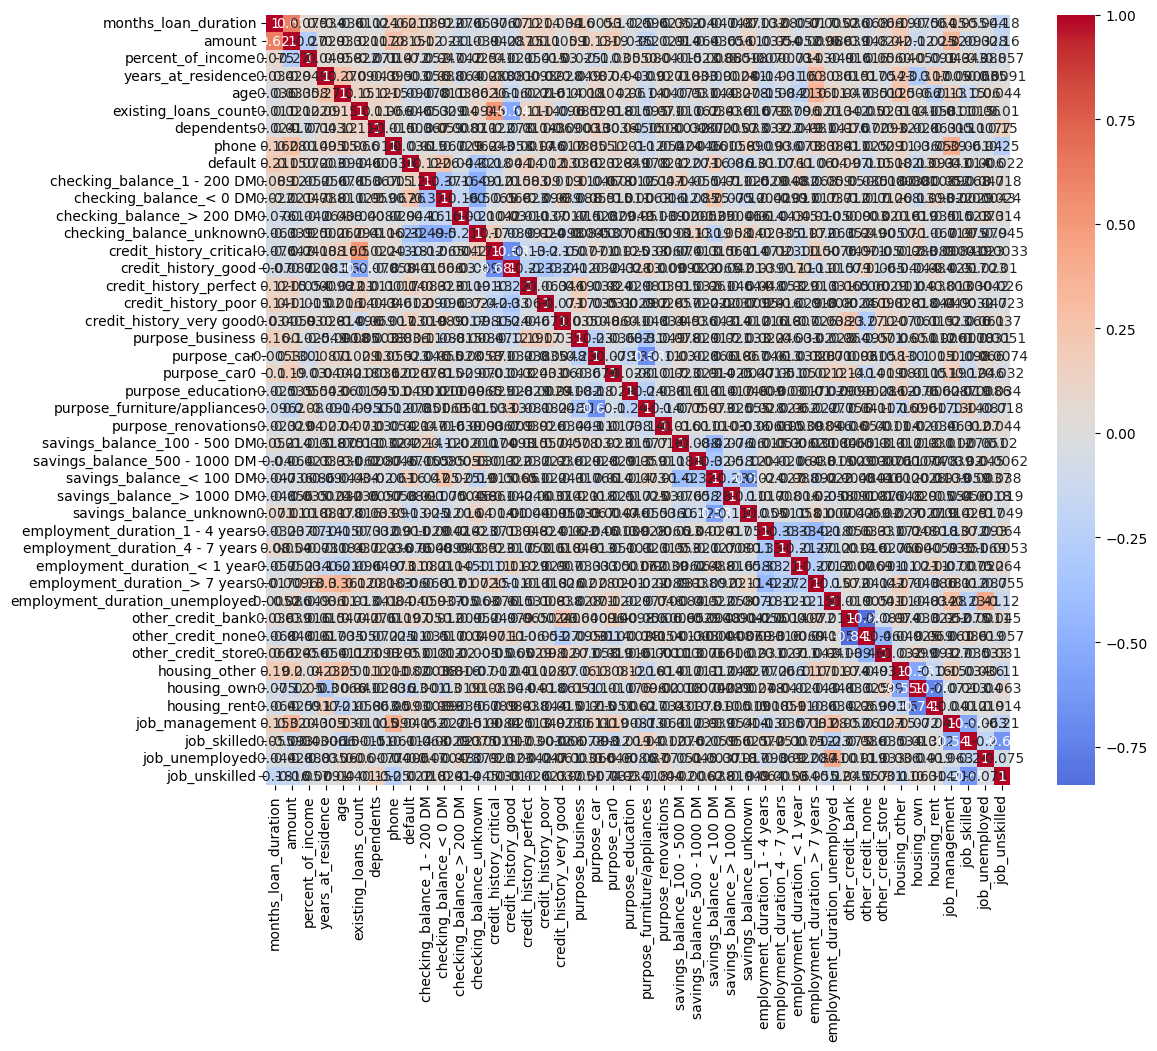

In [6]:
# making correlation heatmap to visualize the correlation between features and the target variable
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', center=0)

In [7]:
#**8. Split the data into training and testing sets.**

target = 'default'

X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 43), (200, 43), (800,), (200,))

In [8]:
# getting the list of numeric features
all_features = df.columns.tolist()
numeric_col = []
for c in all_features: 
    if c not in cat_col:
        numeric_col.append(c)

numeric_col
# applying numeric feature preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


In [9]:

#**9. Apply the decision tree algorithm.**
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

#**11. Find the best predictor features.**
feature_importance = dt.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
importance_df = importance_df.sort_values(by='importance', ascending=False)
importance_df

,feature,importance
1,amount,0.202680
4,age,0.123316
11,checking_balance_unknown,0.090926
0,months_loan_duration,0.089642
2,percent_of_income,0.050155
21,purpose_furniture/appliances,0.039989
13,credit_history_good,0.029972
30,employment_duration_< 1 year,0.029578
25,savings_balance_< 100 DM,0.024874
34,other_credit_none,0.022740


<BarContainer object of 43 artists>

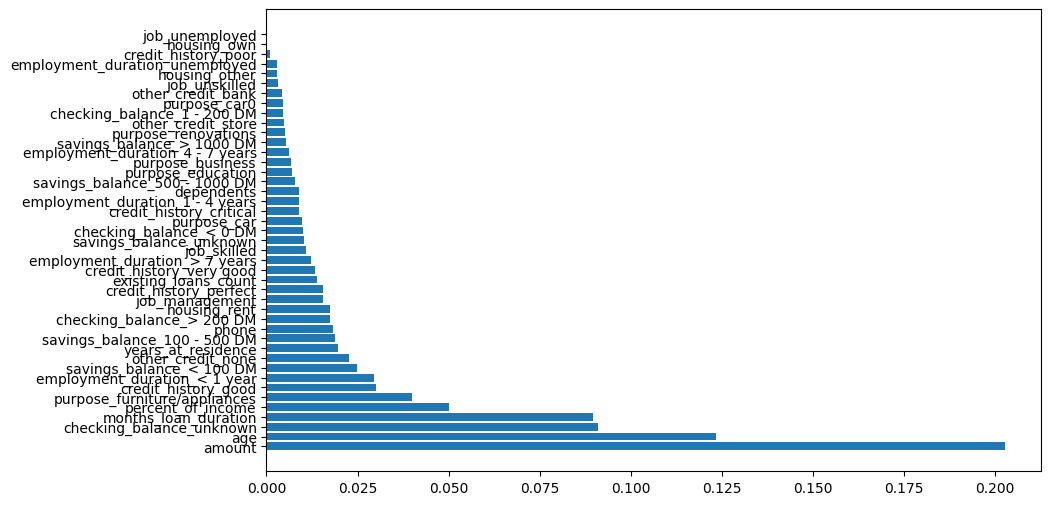

In [10]:
#**10. Visualize the model after training**
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])

In [11]:
#**12. Check the accuracy of the model. Check other metrics.**

y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")


Accuracy: 0.6700
Precision: 0.4507
Recall: 0.5424
F1 Score: 0.4923
ROC AUC Score: 0.6329


Text(0.5, 1.0, 'Confusion Matrix')

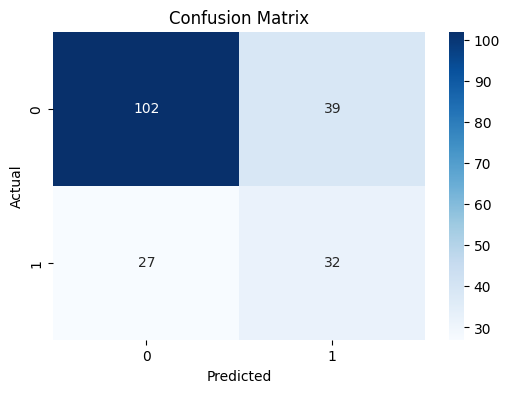

In [12]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')


In [13]:
#**14. How can you improve the performance of your decision tree model?**
# A decision tree can be improved by pruning

#**15. Apply different ways of improve the model. Discuss and explain your results.**
# Pruning-only improvement using Cost-Complexity Pruning (ccp_alpha)
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def eval_classifier(name, model, X_test, y_test):
    y_hat = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_score)
    else:
        roc = np.nan

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_hat),
        "precision": precision_score(y_test, y_hat, zero_division=0),
        "recall": recall_score(y_test, y_hat, zero_division=0),
        "f1": f1_score(y_test, y_hat, zero_division=0),
        "roc_auc": roc,
    }

# --- Baseline decision tree (already trained above as dt) ---
baseline_dt = dt
baseline_metrics = eval_classifier("DecisionTree (baseline)", baseline_dt, X_test, y_test)

# --- Get candidate alphas from pruning path ---
dt_for_path = DecisionTreeClassifier(random_state=42)
path = dt_for_path.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Remove duplicates + keep a reasonable range (optional safety)
ccp_alphas = np.unique(ccp_alphas)

# --- Choose best alpha via cross-validation (optimize F1) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

alpha_scores = []
for a in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=a)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    alpha_scores.append((a, scores.mean()))

alpha_scores = sorted(alpha_scores, key=lambda x: x[1], reverse=True)
best_alpha, best_cv_f1 = alpha_scores[0]

print("Best ccp_alpha:", best_alpha)
print("Best CV F1:", best_cv_f1)

# --- Train pruned model using best alpha ---
pruned_dt = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_dt.fit(X_train, y_train)

pruned_metrics = eval_classifier("DecisionTree (pruned)", pruned_dt, X_test, y_test)

results = pd.DataFrame([baseline_metrics, pruned_metrics]).sort_values("f1", ascending=False)
results


Best ccp_alpha: 0.004922727272727266
Best CV F1: 0.5239475142377139


,model,accuracy,precision,recall,f1,roc_auc
1,DecisionTree (pruned),0.745,0.568966,0.559322,0.564103,0.747866
0,DecisionTree (baseline),0.670,0.450704,0.542373,0.492308,0.632889
